In [ ]:
# 'import' es una palabra reservada para traer librerías externas a nuestro código.
import numpy as np
import pandas as pd

# 'np.random.seed(42)' fija una "semilla" para que los datos aleatorios sean siempre los mismos cada vez que ejecutes.
np.random.seed(42)

# ----- 1. ARCHIVO DE USUARIOS -----
# Asignamos 2500 registros para tener un conjunto de datos más grande
num_datos = 2500

# Creamos un diccionario donde las 
data_usuarios = {
    'ID_Usuario': range(1, num_datos + 1),
    'Edad': np.random.randint(18, 75, size=num_datos),
    'Ingreso_Anual': np.random.randint(25000, 120000, size=num_datos)
}
# 'pd.DataFrame' convierte el diccionario en una tabla estructurada de pandas.
df_usuarios = pd.DataFrame(data_usuarios)
# Guardamos la tabla en un archivo físico.
df_usuarios.to_csv('usuarios_simulados.csv', index=False)


# ----- 2. ARCHIVO DE VEHÍCULOS -----
# Simulamos las características de los autos
data_vehiculos = {
    'ID_Vehiculo': range(1001, 1001 + num_datos),
    'ID_Usuario': range(1, num_datos + 1), # Relacionamos con el dueño
    'Año_Fabricacion': np.random.randint(2005, 2024, size=num_datos),
    'Kilometraje': np.random.randint(10000, 250000, size=num_datos),
    'Tipo_Combustible': np.random.choice(['Gasolina', 'Diesel', 'Hibrido'], size=num_datos)
}
df_vehiculos = pd.DataFrame(data_vehiculos)
# Inyectamos intencionalmente algunos datos nulos (NaN) para practicar la limpieza.
df_vehiculos.loc[50:80, 'Kilometraje'] = np.nan
df_vehiculos.to_csv('vehiculos_simulados.csv', index=False)


# ----- 3. ARCHIVO DE VENTAS -----
# Calculamos un precio de venta simulado dependiente del año y el kilometraje.
# Fórmula oculta: Base + (Año)*bono - (Kilometraje)*descuento + factor aleatorio
precios_simulados = 8000 + (df_vehiculos['Año_Fabricacion'] - 2000) * 500 - (df_vehiculos['Kilometraje'] * 0.04) + np.random.randint(500, 2000, size=num_datos)

# Evitamos que existan precios negativos por algún error matemático
precios_simulados = np.where(precios_simulados < 1500, 1500, precios_simulados)

data_ventas = {
    'ID_Venta': range(5001, 5001 + num_datos),
    'ID_Vehiculo': range(1001, 1001 + num_datos), # Relacionamos con el vehículo
    'Precio_Venta': precios_simulados,
    'Accidentes_Previos': np.random.randint(0, 4, size=num_datos)
}
df_ventas = pd.DataFrame(data_ventas)
df_ventas.to_csv('ventas_simuladas.csv', index=False)

print("Los 3 archivos (Usuarios, Vehículos, Ventas) han sido creados exitosamente con 2500 registros.")

Los 3 archivos (Usuarios, Vehículos, Ventas) han sido creados exitosamente con 2500 registros.


In [ ]:
# 'pd.read_csv' lee el archivo físico y lo carga a la memoria como DataFrame.
usuarios = pd.read_csv('usuarios_simulados.csv')
vehiculos = pd.read_csv('vehiculos_simulados.csv')
ventas = pd.read_csv('ventas_simuladas.csv')

# --- COMBINACIÓN (MERGE) ---
# Primero unimos usuarios y vehículos usando 'ID_Usuario'.
datos_temp = pd.merge(usuarios, vehiculos, on='ID_Usuario', how='inner')

# Luego unimos el resultado anterior con las ventas usando 'ID_Vehiculo'.
df_final = pd.merge(datos_temp, ventas, on='ID_Vehiculo', how='inner')

# --- LISTAR COLUMNAS ---
columnas = df_final.columns.tolist()

print("Las columnas combinadas de los 3 archivos son:")
for col in columnas:
    print("-", col)

Las columnas combinadas de los 3 archivos son:
- ID_Usuario
- Edad
- Ingreso_Anual
- ID_Vehiculo
- Año_Fabricacion
- Kilometraje
- Tipo_Combustible
- ID_Venta
- Precio_Venta
- Accidentes_Previos


In [ ]:
print("--- ANÁLISIS INICIAL ---")
df_final.info()

print("\n--- LIMPIEZA DE DATOS ---")
# '.isnull().sum()' cuenta cuántos valores vacíos (nulos) hay.
nulos_antes = df_final.isnull().sum()
print("Valores nulos antes de limpiar:\n", nulos_antes)

# Calculamos la mediana del kilometraje para rellenar los datos que dañamos a propósito.
mediana_km = df_final['Kilometraje'].median()

# '.fillna()' busca los vacíos y los rellena con la mediana.
df_final['Kilometraje'].fillna(mediana_km, inplace=True)

# Limpiamos duplicados.
df_final.drop_duplicates(inplace=True)

print("\nLimpieza completada. Datos listos para analizar.")

--- ANÁLISIS INICIAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Usuario          2500 non-null   int64  
 1   Edad                2500 non-null   int64  
 2   Ingreso_Anual       2500 non-null   int64  
 3   ID_Vehiculo         2500 non-null   int64  
 4   Año_Fabricacion     2500 non-null   int64  
 5   Kilometraje         2469 non-null   float64
 6   Tipo_Combustible    2500 non-null   object 
 7   ID_Venta            2500 non-null   int64  
 8   Precio_Venta        2469 non-null   float64
 9   Accidentes_Previos  2500 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 195.4+ KB

--- LIMPIEZA DE DATOS ---
Valores nulos antes de limpiar:
 ID_Usuario             0
Edad                   0
Ingreso_Anual          0
ID_Vehiculo            0
Año_Fabricacion        0
Kilometraje           31
Tipo_C

/tmp/ipykernel_2188/3237495056.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Kilometraje'].fillna(mediana_km, inplace=True)


/tmp/ipykernel_2188/770913620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Tipo_Combustible', palette='magma')


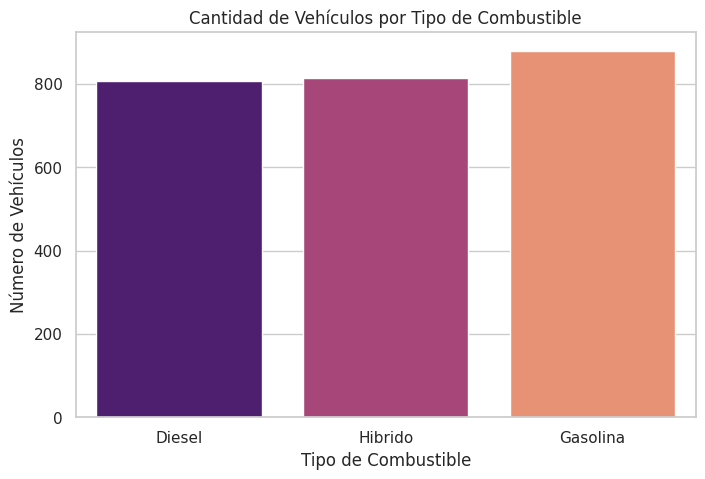

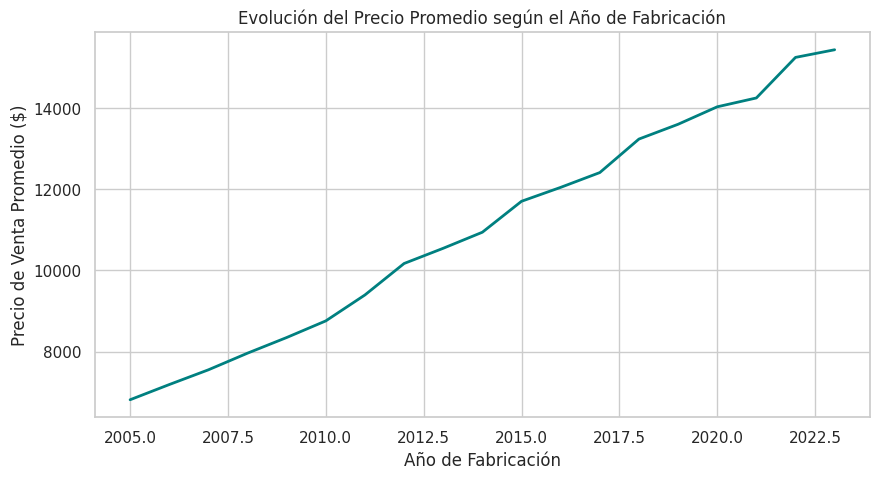

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- 1. GRÁFICA DE BARRAS ---
plt.figure(figsize=(8, 5))
# Contamos cuántos vehículos hay por tipo de combustible
sns.countplot(data=df_final, x='Tipo_Combustible', palette='magma')
plt.title('Cantidad de Vehículos por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Número de Vehículos')
plt.show()

# --- 2. GRÁFICA DE LÍNEAS ---
plt.figure(figsize=(10, 5))
# Agrupamos los datos por 'Año_Fabricacion' y sacamos el promedio del Precio.
precio_por_año = df_final.groupby('Año_Fabricacion')['Precio_Venta'].mean()

sns.lineplot(x=precio_por_año.index, y=precio_por_año.values, color='teal', linewidth=2)
plt.title('Evolución del Precio Promedio según el Año de Fabricación')
plt.xlabel('Año de Fabricación')
plt.ylabel('Precio de Venta Promedio ($)')
plt.show()

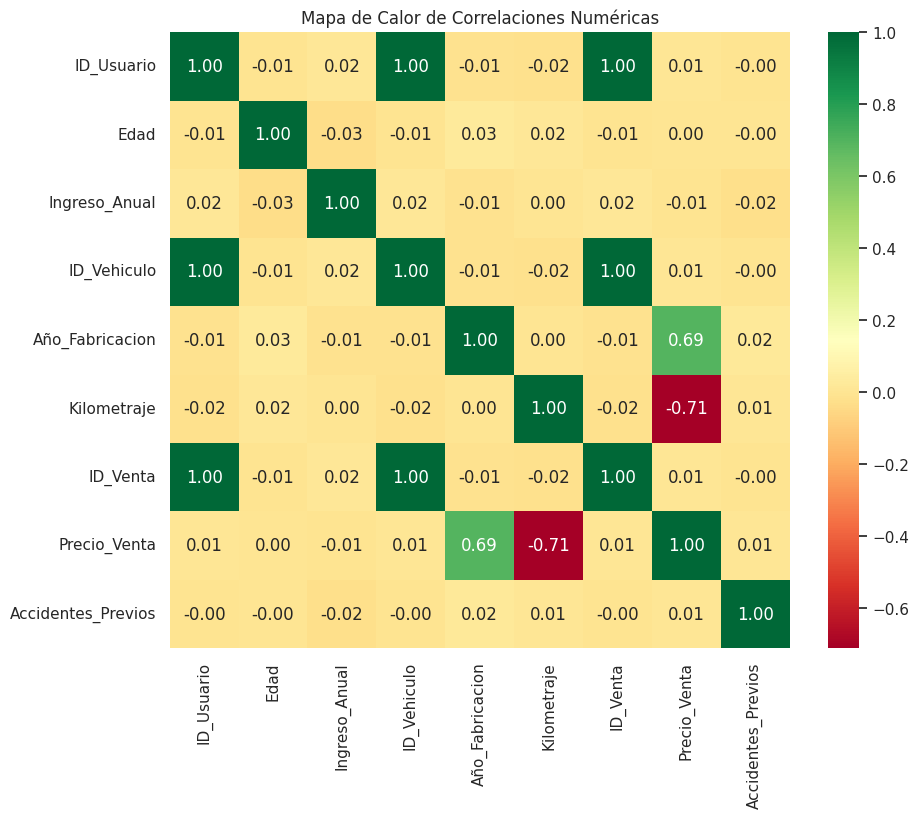

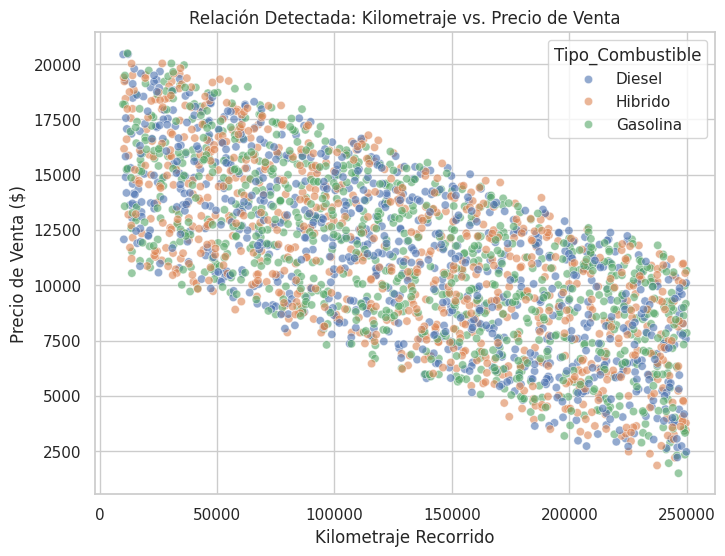

In [ ]:
# --- 1. MAPA DE CALOR ---
plt.figure(figsize=(10, 8))
# Filtramos solo columnas numéricas
datos_numericos = df_final.select_dtypes(include=[np.number])

correlacion = datos_numericos.corr()

# 'sns.heatmap()' dibuja el mapa.
sns.heatmap(correlacion, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()

# --- 2. GRÁFICA DE DISPERSIÓN (SCATTERPLOT) ---
# En el mapa verás que el Kilometraje tiene una correlación negativa fuerte con el precio (a más km, menos precio).
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final, x='Kilometraje', y='Precio_Venta', hue='Tipo_Combustible', palette='deep', alpha=0.6)
plt.title('Relación Detectada: Kilometraje vs. Precio de Venta')
plt.xlabel('Kilometraje Recorrido')
plt.ylabel('Precio de Venta ($)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparación: Convertimos texto a números para que la IA lo entienda
df_final['Combustible_Num'] = df_final['Tipo_Combustible'].map({'Gasolina': 1, 'Diesel': 2, 'Hibrido': 3})

# Imputar los valores NaN en 'Precio_Venta' antes de usarlo como objetivo
# Calculamos la mediana del Precio_Venta
mediana_precio_venta = df_final['Precio_Venta'].median()
# Rellenamos los valores NaN con la mediana
df_final['Precio_Venta'] = df_final['Precio_Venta'].fillna(mediana_precio_venta)

# ==========================================
# FASE 1: MODELO BÁSICO (Iteración inicial)
# ==========================================
# Le pedimos a la IA que intente predecir el precio basándose ÚNICAMENTE en el kilometraje.
X_basico = df_final[['Kilometraje']]
y_objetivo = df_final['Precio_Venta']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_basico, y_objetivo, test_size=0.2, random_state=42)

modelo_basico = LinearRegression()
modelo_basico.fit(X_train_b, y_train_b)
precision_basica = r2_score(y_test_b, modelo_basico.predict(X_test_b))

print("--- RESULTADOS FASE 1 (Modelo Básico) ---")
print(f"Precisión solo usando Kilometraje: {precision_basica * 100:.2f}%\n")


# ==========================================
# FASE 2: MODELO MEJORADO (Iteración final)
# ==========================================
# Ahora le damos a la IA todo el contexto: Edad del dueño, Año, Kilometraje y Combustible.
X_mejorado = df_final[['Edad', 'Año_Fabricacion', 'Kilometraje', 'Combustible_Num']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mejorado, y_objetivo, test_size=0.2, random_state=42)

modelo_mejorado = LinearRegression()
modelo_mejorado.fit(X_train_m, y_train_m)
predicciones = modelo_mejorado.predict(X_test_m)

precision_mejorada = r2_score(y_test_m, predicciones)
error_cuadratico = mean_squared_error(y_test_m, predicciones)

print("--- RESULTADOS FASE 2 (Modelo Mejorado) ---")
print(f"Nueva Precisión (R2 Score): {precision_mejorada * 100:.2f}%")
print(f"Error Cuadrático Medio: {error_cuadratico:.2f}\n")


# ==========================================
# MULTIPLES EJEMPLOS DE PREDICCIÓN EN VIVO
# ==========================================
print("--- SIMULADOR DE PRECIOS PARA CLIENTES ---")
# Estructura requerida: ['Edad', 'Año_Fabricacion', 'Kilometraje', 'Combustible_Num']

# Ejemplo A: Un universitario de 22 años vende un auto reciente pero bastante usado.
cliente_1 = pd.DataFrame([[22, 2022, 95000, 1]], columns=X_mejorado.columns)
precio_1 = modelo_mejorado.predict(cliente_1)
print(f"Caso 1 (Auto 2022, 95k km): La IA sugiere venderlo en -> ${precio_1[0]:.2f}")

# Ejemplo B: Un señor de 60 años vende una joya guardada en su garaje (viejo pero sin uso).
cliente_2 = pd.DataFrame([[60, 2005, 15000, 2]], columns=X_mejorado.columns)
precio_2 = modelo_mejorado.predict(cliente_2)
print(f"Caso 2 (Auto 2005, solo 15k km): La IA sugiere venderlo en -> ${precio_2[0]:.2f}")

# Ejemplo C: Familia vende un híbrido estándar con uso promedio.
cliente_3 = pd.DataFrame([[35, 2017, 60000, 3]], columns=X_mejorado.columns)
precio_3 = modelo_mejorado.predict(cliente_3)
print(f"Caso 3 (Auto 2017 Híbrido, 60k km): La IA sugiere venderlo en -> ${precio_3[0]:.2f}")

--- RESULTADOS FASE 1 (Modelo Básico) ---
Precisión solo usando Kilometraje: 49.36%

--- RESULTADOS FASE 2 (Modelo Mejorado) ---
Nueva Precisión (R2 Score): 98.27%
Error Cuadrático Medio: 248524.34

--- SIMULADOR DE PRECIOS PARA CLIENTES ---
Caso 1 (Auto 2022, 95k km): La IA sugiere venderlo en -> $16410.69
Caso 2 (Auto 2005, solo 15k km): La IA sugiere venderlo en -> $11218.68
Caso 3 (Auto 2017 Híbrido, 60k km): La IA sugiere venderlo en -> $15325.65
